In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [4]:
img1 = cv2.imread(r"C:\Users\Hp\Pictures\OpenCVSamples\arithmetic-operations\arithmetic operations\input1.jpg")
img2 = cv2.imread(r"C:\Users\Hp\Pictures\OpenCVSamples\arithmetic-operations\arithmetic operations\input2.jpg")

Before applying arithmetic operations, it is useful to display both images side by side for comparison. If the images have different dimensions, resize one image so that both have the same size.

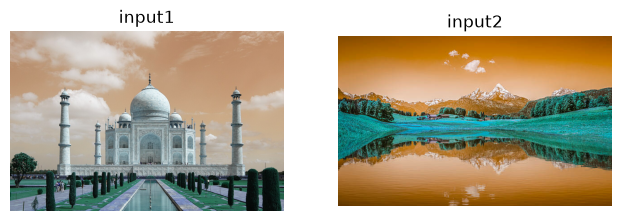

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.title('input1')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img2)
plt.title('input2')
plt.axis('off')


plt.show()

Think of a subplot figure like a table.

plt.subplot(rows, cols, pos) means:

rows = how many horizontal lines the table has
cols = how many columns (slots) the table has
pos = which slot to draw into (left to right)
Example: plt.subplot(1, 3, 1)

1 row
3 columns (3 slots)
pos=1 → the left slot
Example: plt.subplot(1, 3, 2)

1 row
3 columns
pos=2 → the middle slot
So the parameters differ because you must tell Matplotlib: “draw img1 in slot 1” and “draw img2 in slot 2” to get side-by-side.

Easier example (2 images side-by-side):


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # left slot
plt.imshow(img1)
plt.axis('off')

plt.subplot(1, 2, 2)  # right slot
plt.imshow(img2)
plt.axis('off')

plt.show()

plt.figure() and plt.subplot() work together like this:

plt.figure(): creates a new canvas/window (a new figure).
plt.subplot(rows, cols, pos): divides that canvas into a grid and selects one grid cell to draw the next plot.

In [ ]:
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

line_thickness = 5
height = img1.shape[0]
line = np.full((height, line_thickness, 3), (0, 0, 255), dtype=np.uint8)

side_by_side = np.hstack((img1, line, img2))

side_by_side_rgb = cv2.cvtColor(side_by_side, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(side_by_side_rgb)
plt.title('input1 input2')
plt.axis('off')
plt.show()

In [12]:
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
else:
    print('images have the same size')

images have the same size


Phase 2: Image Enhancement & Blending
Now you will combine the two images in different mathematical ways. 3. Simple Addition: Use cv2.add() to add the two images together. This adds the pixel values using saturation, meaning the colors will max out at 255 (pure white) rather than rolling over


. 4. Weighted Addition: Create a smooth double-exposure effect using cv2.addWeighted(). You will blend the two images by passing them in with specified weights (for example, 0.7 and 0.3 to dictate how much each image contributes) and a gamma value of 0 (which controls overall brightness adjustment)

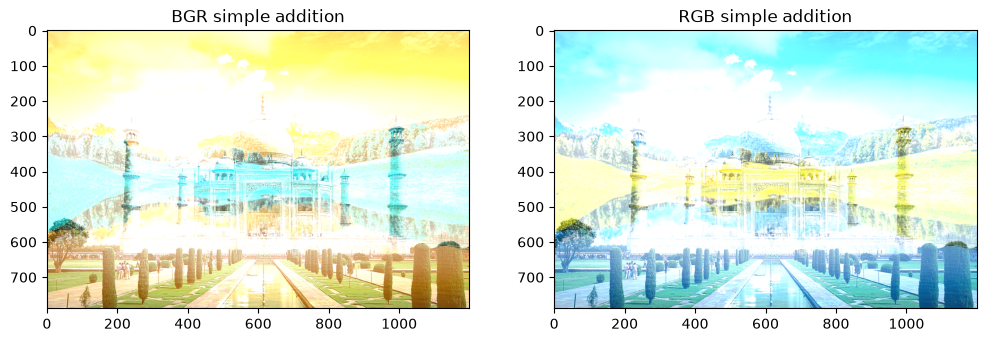

In [19]:
simple_add = cv2.add(img1 , img2)

plt.figure(figsize=(12,6))

# displayes image in BGR
plt.subplot(1,2,1)
plt.imshow(simple_add) 
plt.title("BGR simple addition")

# displayes image in RGB
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(simple_add , cv2.COLOR_BGR2RGB))
plt.title("RGB simple addition")

plt.show()


Difference between plt.imshow and plt.show
1) plt.imshow(...)

What it does: actually draws/places the image on the current figure (canvas).
Used for: showing arrays/images (your img, img1, img2).
It does not control when the window appears; it just adds visuals to the figure.

plt.imshow(img1)  # draw image in the selected subplot/figure


2) plt.show()

What it does: renders the figure to the screen (i.e., makes the window/figure appear).
Used for: when you’re done plotting everything you want on that figure.

plt.show()  # display the whole figure (all subplots) at once
When to use which
Typical pattern for multiple subplots (recommended):


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)

plt.subplot(1, 2, 2)
plt.imshow(img2)

plt.show()  # show after all images are placed

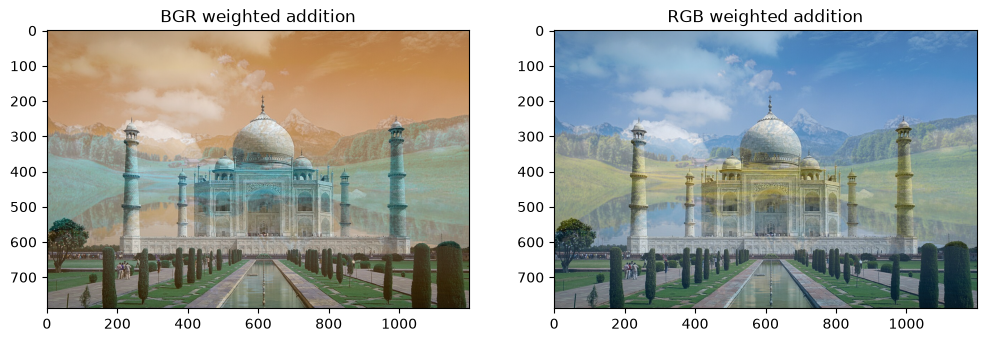

In [ ]:
weighted_add = cv2.addWeighted(img1 , 0.7 , img2 , 0.3 , 0)

plt.figure(figsize=(12,6))

# displayes image in BGR
plt.subplot(1,2,1)
plt.imshow(weighted_add) 
plt.title("BGR weighted addition")

# displayes image in RGB
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(weighted_add , cv2.COLOR_BGR2RGB))
plt.title("RGB weighted addition")

plt.show()

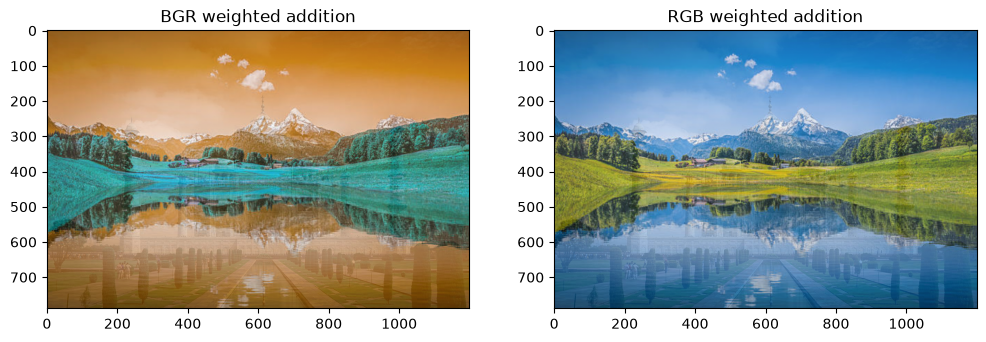

In [22]:
weighted_add2 = cv2.addWeighted(img1 , 0.2 , img2 , 0.8 , 2)

plt.figure(figsize=(12,6))


# displayes image in BGR
plt.subplot(1,2,1)
plt.imshow(weighted_add2) 
plt.title("BGR weighted addition")

# displayes image in RGB
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(weighted_add2 , cv2.COLOR_BGR2RGB))
plt.title("RGB weighted addition")

plt.show()

Phase 3: Change Detection & Background Subtraction
Next, you will isolate the differences between the two images. 

Image Subtraction: Use cv2.subtract() to subtract the pixels of the second image from the first
. 6. Analyze: Observe the output. Any negative values resulting from the math are automatically clipped to 0 (pure black)
. This specific operation is fundamentally used for tasks like change detection and background subtraction in real-world applications